<a href="https://colab.research.google.com/github/jostina/Week-1-2-Data-Cleaning-Exploratory-Data-Analysis/blob/main/Week_3_Statistics_%26_Probability_Titanic_Dataset_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load Dataset
df = pd.read_csv("/content/titanic_cleaned.csv")


In [ ]:

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,HasCabin,FamilySize,IsAlone,Title,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0,2,0,Mr,Young Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1,2,0,Mrs,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,1,1,Miss,Young Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1,2,0,Mrs,Young Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0,1,1,Mr,Young Adult


# 1. Descriptive Statistics

In [ ]:

# Mean
mean_age = df['Age'].mean()
mean_fare = df['Fare'].mean()

print(f"Mean Age: {mean_age:.2f}")
print(f"Mean Fare: {mean_fare:.2f}")

Mean Age: 29.11
Mean Fare: 32.20


In [ ]:
# Variance
variance_age = df['Age'].var()
variance_fare = df['Fare'].var()

print(f"Variance of Age: {variance_age:.2f}")
print(f"Variance of Fare: {variance_fare:.2f}")

Variance of Age: 177.01
Variance of Fare: 2469.44


In [ ]:
# Standard Deviation
std_age = df['Age'].std()
std_fare = df['Fare'].std()

print(f"Standard Deviation of Age: {std_age:.2f}")
print(f"Standard Deviation of Fare: {std_fare:.2f}")


Standard Deviation of Age: 13.30
Standard Deviation of Fare: 49.69


In [ ]:
# Summary statistics
print("\nSummary Statistics")
print(df[['Age', 'Fare']].describe())


Summary Statistics
              Age        Fare
count  891.000000  891.000000
mean    29.112424   32.204208
std     13.304424   49.693429
min      0.420000    0.000000
25%     21.500000    7.910400
50%     26.000000   14.454200
75%     36.000000   31.000000
max     80.000000  512.329200


# Visualization of distributions

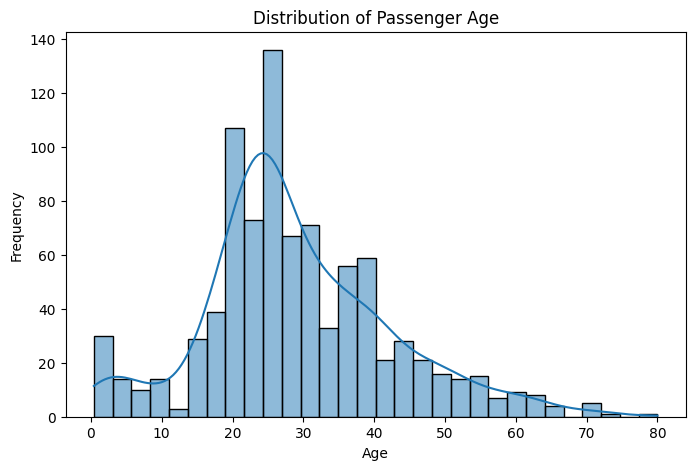

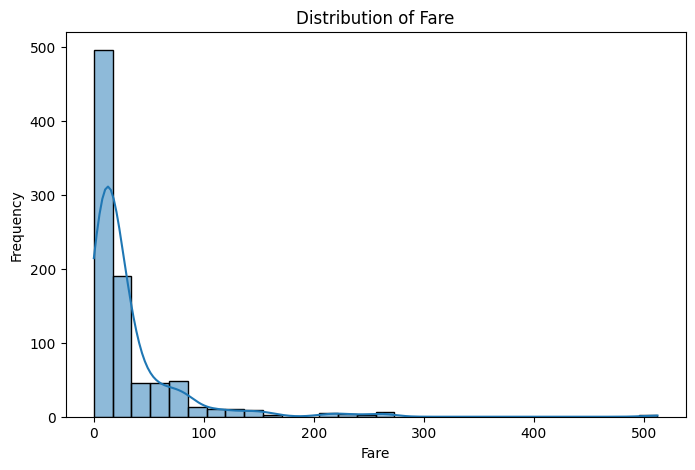

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df['Fare'], bins=30, kde=True)
plt.title("Distribution of Fare")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

# 2. Probability Distributions

In [ ]:
# Check skewness
age_skew = df['Age'].skew()
fare_skew = df['Fare'].skew()

print(f"Age Skewness: {age_skew:.2f}")
print(f"Fare Skewness: {fare_skew:.2f}")

Age Skewness: 0.53
Fare Skewness: 4.79


In [ ]:
if abs(age_skew) < 0.5:
    print("Age is approximately normally distributed.")
else:
    print("Age is not normally distributed.")

if abs(fare_skew) < 0.5:
    print("Fare is approximately normally distributed.")
else:
    print("Fare is positively skewed.")

Age is not normally distributed.
Fare is positively skewed.


# 3. Hypothesis Testing

In [ ]:
# Create contingency table
contingency_table = pd.crosstab(df['Pclass'], df['Survived'])

# Chi-square test
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-square Statistic: {chi2:.4f}")
print(f"P-value: {p:.6f}")

Chi-square Statistic: 102.8890
P-value: 0.000000


In [ ]:
alpha = 0.05

if p < alpha:
    print("Reject the Null Hypothesis")
    print("Passenger Class significantly affects survival.")
else:
    print("Fail to Reject the Null Hypothesis")
    print("Passenger Class does not significantly affect survival.")

Reject the Null Hypothesis
Passenger Class significantly affects survival.


# 4. Correlation vs Causation

In [ ]:
# Select numerical columns
numeric_columns = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
correlation_matrix = numeric_columns.corr()

print(correlation_matrix['Survived'].sort_values(ascending=False))


Survived       1.000000
HasCabin       0.316912
Fare           0.257307
Parch          0.081629
FamilySize     0.016639
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.059579
IsAlone       -0.203367
Pclass        -0.338481
Name: Survived, dtype: float64


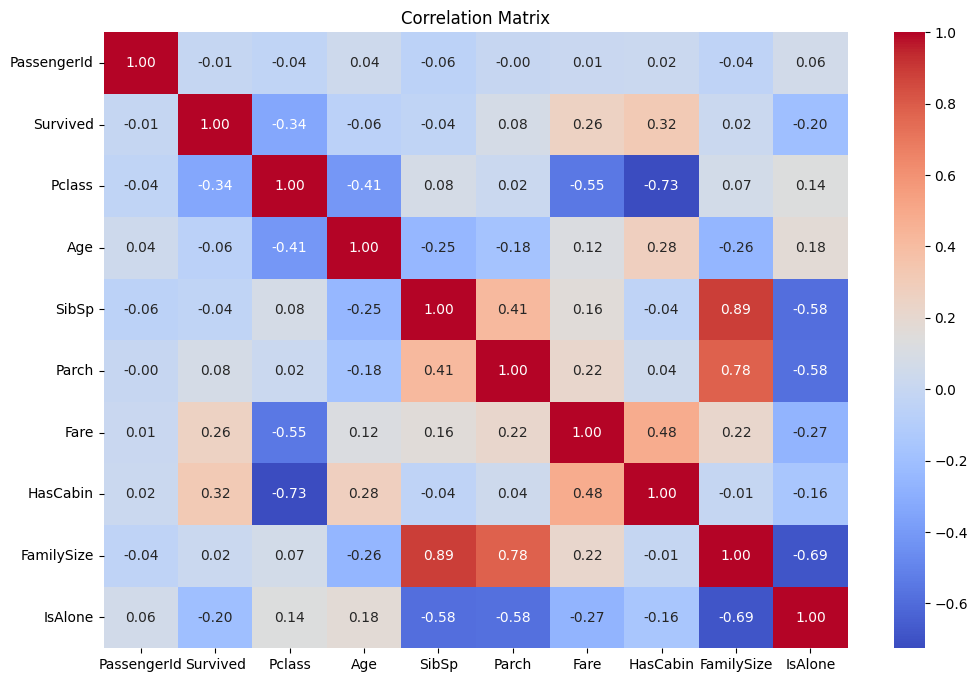

In [ ]:
# Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()